# 中間表現の動作の説明

このノートブックでは、中間表現（IR, Intermediate Representation）を `qret` コマンドを使って読み取る手順を確認します。
IR は Quration ライブラリの中心であるため、構造を把握しておくことでライブラリの理解が深まります。
本章では以下の 3 つのサブコマンドの使い方を確認しつつ、中間表現について説明します。

- `print` :命令列をプリントする。
- `diagram` :量子回路に関する様々な図を作成する。
- `simulate` :量子回路をシミュレートする。

本章で扱う対象は `quration-core/examples/data/circuit/add_craig_5.json` で、以下では `example.json` として扱います。

本章で到達する目標は次のとおりです。

- `qret print` を用いて、IR の関数単位・命令単位の構造を読み解けるようにする。
- `FunctionCall` と `BasicBlock` の位置関係を追跡し、分岐や呼び出しの挙動を説明できるようにする。
- `diagram` の各種図と `simulate` の結果を照合し、構造理解と意味論確認を一貫して行えるようにする。

まずは実行環境と入力ファイルを準備します。
以下のコードでは、 `qret` の実行パスはビルド結果を前提にしていますが、環境に応じて適切な値をセットしてください。

In [1]:
import pathlib
import os

import graphviz
from IPython.display import Code

project_root = pathlib.Path("../..").resolve()
qret_path = project_root / "build" / "main"
example_path = project_root / "quration-core" / "examples" / "data" / "circuit" / "add_craig_5.json"

os.environ["PATH"] = str(qret_path) + os.pathsep + os.environ.get("PATH", "")

`qret` が実行可能であることを確認します。

In [2]:
!qret --version

Quration: Quantum Resource Estimation Toolchain for FTQC version 1.0.0


入力 JSON を確認します。

In [3]:
Code(filename=example_path, language="json")

{
    "metadata": {
        "format": "IR",
        "schema_version": "0.1",
        "qret_version": "0.6.1",
        "created_at": "2025-09-29T06:54:48"
    },
    "name": "craig",
    "circuit_list": [
        {
            "name": "AddCraig(5)",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "Clean",
                            "q": 10
                        },
                        {
                            "opcode": "Clean",
                            "q": 11
                        },
                        {
                            "opcode": "Clean",
                            "q": 12
                        },
                        {
                            "opcode": "Clean",
                            "q": 13
                        },
                        {
                            "opcode": "Call",
                            "callee": "TemporalAnd",
                            "operate": [
                                10,
                                5,
                                0
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                            "opcode": "CX",
                            "q0": 6,
                            "q1": 10
                        },
                        {
                            "opcode": "CX",
                            "q0": 1,
                            "q1": 10
                        },
                        {
                            "opcode": "Call",
                            "callee": "TemporalAnd",
                            "operate": [
                                11,
                                6,
                                1
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                            "opcode": "CX",
                            "q0": 11,
                            "q1": 10
                        },
                        {
                            "opcode": "CX",
                            "q0": 7,
                            "q1": 11
                        },
                        {
                            "opcode": "CX",
                            "q0": 2,
                            "q1": 11
                        },
                        {
                            "opcode": "Call",
                            "callee": "TemporalAnd",
                            "operate": [
                                12,
                                7,
                                2
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                            "opcode": "CX",
                            "q0": 12,
                            "q1": 11
                        },
                        {
                            "opcode": "CX",
                            "q0": 8,
                            "q1": 12
                        },
                        {
                            "opcode": "CX",
                            "q0": 3,
                            "q1": 12
                        },
                        {
                            "opcode": "Call",
                            "callee": "TemporalAnd",
                            "operate": [
                                13,
                                8,
                                3
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                

## qret print

`print` は IR の命令列を確認するサブコマンドです。

この章では `print` について、次の観点を順番に確認します。

- モジュール全体像の把握（関数数・関数名・引数の有無）
- 関数内部での命令列の並び（`Call`、測定、分岐、基本命令）
- 必要に応じた展開深度（`-d`）で、呼び出し階層をどこまで展開するか

In [4]:
!qret print --help

qret 'print' options:
  -h [ --help ]           Show this help and exit.
  --quiet                 Suppress non-error output.
  --verbose               Enable verbose logging (more detail than default).
  --debug                 Enable debug logging (most detailed; implies 
                          --verbose).
  --color                 Enable colored output.
  -i [ --input ] arg      Path to input IR file.
  -s [ --summary ]        Print summary only. If --function is omitted, print 
                          module summary.
  -f [ --function ] NAME  Function name to print; with --summary prints only 
                          the function summary.
  -d [ --depth ] arg (=1) Descend only 'depth' call deep
  --print_debug_info      Print debug info


まず `print -s` で対象モジュールの要約を確認し、どの関数が含まれるかを把握します。

In [5]:
!qret print -i {example_path} -s

[Module Summary]
  name                  : craig
  function_count        : 3
  functions:
    - AddCraig(5)
    - TemporalAnd
    - UncomputeTemporalAnd


次に `UncomputeTemporalAnd` 関数についての要約を `print -s` で確認します。

量子ビット数、基本ブロック数、命令数などを確認できます。

In [6]:
!qret print -i {example_path} -s -f "UncomputeTemporalAnd"

[Function Summary]
  module                : craig
  function              : UncomputeTemporalAnd
  basic_block_count     : 3
  instruction_count     : 8
  qubit_count           : 3
  register_count        : 0
  tmp_register_count    : 1
  contains_measurement  : yes


### FunctionCall（関数呼び出し）の見方

`print` サブコマンドで具体的に回路の命令列を表示します。

In [7]:
!qret print -i {example_path} -f "UncomputeTemporalAnd"

[Function]
UncomputeTemporalAnd:
 [block] entry
  H @q0
  Measurement @q0 @r0
  Branch @r0 %then_0 %if_cont_0
 [block] then_0
  X @q0
  CZ @q1 @q2
  Branch %if_cont_0
 [block] if_cont_0
  Return


`print` の命令列で `Call` が現れた場合は、`FunctionCall` に相当します。
この表現が示すのは、制御フロー上の「呼び出し」だけではなく、
引数束縛と戻り関係を含めた構造の移動です。
読む際は、次の 2 点をセットで確認すると解釈しやすくなります。

- **呼び出し先関数（callee）**: どの関数へ移るのか
- **引数の対応（operate 等）**: 呼び出し側の演算対象がどのように渡されるのか

`AddCraig(5)` のように再利用関数が多い回路では、`Call` の連鎖を先に追うことで、
上位関数の意味を崩さずに全体像を掴みやすくなります。
ネストした呼び出し順が分かると、図上の CallGraph と命令列の対応を自然に合わせやすくなります。

### BasicBlock（基本ブロック）の見方

`FunctionCall` と `BasicBlock` は密接に関連しています。
`BasicBlock` は分岐やジャンプの境界で分割された最小実行単位として扱われます。
そのため、`Call` の流れだけでは見えにくい「どこで分岐し、どこで収束するか」を理解するには、`BasicBlock` 単位の見方が有効です。
`print` で命令列を読む際も、`BasicBlock` を軸に「到達可能ノード」を追うと、分岐条件の影響範囲を見失いにくくなります。

`TemporalAnd` は全体の筋が見えやすい一方、`UncomputeTemporalAnd` では `entry`、`then_0`、`if_cont_0` といった
基本ブロック名が直接登場します。
ここでブロック名と命令列を対応づけると、どの分岐条件でどのパスが選ばれるかまで、読解の幅が広がります。
同じ関数内でも、測定結果に応じて経路が分岐する局面がどこかを素早く見つけられるようになります。

In [8]:
!qret print -i {example_path} -f "TemporalAnd"

[Function]
TemporalAnd:
 [block] entry
  H @q0
  T @q0
  CX @q0 @q1
  CX @q0 @q2
  CX @q1 @q0
  CX @q2 @q0
  TDag @q1
  TDag @q2
  T @q0
  CX @q1 @q0
  CX @q2 @q0
  H @q0
  S @q0
  Return


続けて `AddCraig(5)` を見て、呼び出し元の大枠と内部呼び出しの展開深度（`-d`）が表示にどのように反映されるかを確認します。
まずは展開なしで全体の入口と呼び出し関係を確認し、次に `-d 2` で内部の展開を深めて追跡します。
再帰的に深くなるほど行数は増えますが、どこで再利用が起きているかが同時に見えるため、意図的に深度を上げる価値があります。

In [9]:
!qret print -i {example_path} -f "AddCraig(5)"

[Function]
AddCraig(5):
 [block] entry
  Call @TemporalAnd({@q10 @q5 @q0},{},{})
  CX @q6 @q10
  CX @q1 @q10
  Call @TemporalAnd({@q11 @q6 @q1},{},{})
  CX @q11 @q10
  CX @q7 @q11
  CX @q2 @q11
  Call @TemporalAnd({@q12 @q7 @q2},{},{})
  CX @q12 @q11
  CX @q8 @q12
  CX @q3 @q12
  Call @TemporalAnd({@q13 @q8 @q3},{},{})
  CX @q13 @q12
  CX @q4 @q13
  CX @q13 @q12
  Call @UncomputeTemporalAnd({@q13 @q8 @q3},{},{})
  CX @q8 @q12
  CX @q12 @q11
  Call @UncomputeTemporalAnd({@q12 @q7 @q2},{},{})
  CX @q7 @q11
  CX @q11 @q10
  Call @UncomputeTemporalAnd({@q11 @q6 @q1},{},{})
  CX @q6 @q10
  Call @UncomputeTemporalAnd({@q10 @q5 @q0},{},{})
  CX @q0 @q5
  CX @q1 @q6
  CX @q2 @q7
  CX @q3 @q8
  CX @q4 @q9
  Return


次に `-d 2` を指定し、`FunctionCall` を 2 段階まで展開して読みます。
この出力から、ネストしている呼び出しがどこで終了するか、あるいは別の関数へ継承されるかを確認できます。

In [10]:
!qret print -i {example_path} -f "AddCraig(5)" -d 2

[Function]
AddCraig(5):
 [block] entry
  Call @TemporalAnd({@q10 @q5 @q0},{},{})
  -->
    TemporalAnd:
     [block] entry
      H @q0
      T @q0
      CX @q0 @q1
      CX @q0 @q2
      CX @q1 @q0
      CX @q2 @q0
      TDag @q1
      TDag @q2
      T @q0
      CX @q1 @q0
      CX @q2 @q0
      H @q0
      S @q0
      Return
  <--  (@TemporalAnd)
  CX @q6 @q10
  CX @q1 @q10
  Call @TemporalAnd({@q11 @q6 @q1},{},{})
  -->
    TemporalAnd:
     [block] entry
      H @q0
      T @q0
      CX @q0 @q1
      CX @q0 @q2
      CX @q1 @q0
      CX @q2 @q0
      TDag @q1
      TDag @q2
      T @q0
      CX @q1 @q0
      CX @q2 @q0
      H @q0
      S @q0
      Return
  <--  (@TemporalAnd)
  CX @q11 @q10
  CX @q7 @q11
  CX @q2 @q11
  Call @TemporalAnd({@q12 @q7 @q2},{},{})
  -->
    TemporalAnd:
     [block] entry
      H @q0
      T @q0
      CX @q0 @q1
      CX @q0 @q2
      CX @q1 @q0
      CX @q2 @q0
      TDag @q1
      TDag @q2
      T @q0
      CX @q1 @q0
      CX @q2 @q0
      H @q0
    

この時点で、`FunctionCall` の連鎖と `BasicBlock` 構造をテキストで追跡できる状態になります。
次は同じ情報を図で確認し、分岐や呼び出しの経路を視覚的に固定します。

## qret diagram

`diagram` は IR についての情報を図で表示するためのサブコマンドです。
現在実装している図は以下の 4 つです。

- Control Flow Graph (CFG)
- Call Graph
- 回路図
- Compute Graph

In [11]:
!qret diagram --help

qret 'diagram' options:
  -h [ --help ]             Show this help and exit.
  --quiet                   Suppress non-error output.
  --verbose                 Enable verbose logging (more detail than default).
  --debug                   Enable debug logging (most detailed; implies 
                            --verbose).
  --color                   Enable colored output.
  -i [ --input ] arg        Input file
  --function arg            Function name to draw
  -o [ --output ] arg       Output file (default is 'out.dot' or 'out.tex')
  -g [ --graph-format ] arg Format of diagram to generate ('CFG', 'CallGraph', 
                            'LaTeX', or 'ComputeGraph')
  --display_num_calls       [CallGraph] Display how many times a function is 
                            called


### CFG（制御フロー図）

CFG は、`BasicBlock` 同士の遷移（分岐・継続）をノードとエッジで表現します。
`Function` 内の制御フローを先に固定化しておくと、`print` では追いづらい実行経路の重なりを整理しやすくなります。

図を読む観点は次のとおりです。

- エントリー（`entry`）と終了（`if` 系の継続）を先に確認する
- 分岐条件（測定結果に依存する経路）で、次にどのブロックへ進むかを追う
- 同一命令列でも到達可能ノードが異なるかを比較する

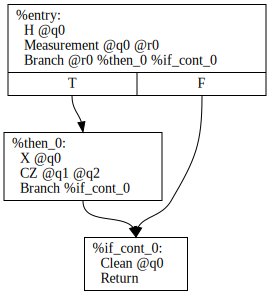

In [12]:
!qret diagram -i {example_path} --function "UncomputeTemporalAnd" --graph-format "CFG" -o cfg.dot

graphviz.Source.from_file("cfg.dot")

### CallGraph

CallGraph は、`FunctionCall` の依存関係をノード・エッジで確認するための図です。
`AddCraig(5)` のような階層化が深い回路では、再利用される関数をこの図で把握すると、
後続の最適化や分解対象の優先度を決めやすくなります。

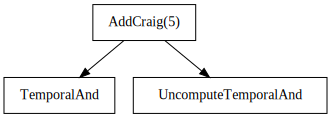

In [13]:
!qret diagram -i {example_path} --function "AddCraig(5)" --graph-format "CallGraph" -o call_graph.dot

graphviz.Source.from_file("call_graph.dot")

呼び出し回数情報を付加すると、同一関数が何度呼び出されているかが見え、
反復コストの高いパスを発見しやすくなります。

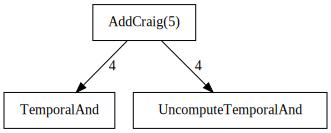

In [14]:
!qret diagram -i {example_path} --function "AddCraig(5)" --graph-format "CallGraph" -o call_graph.dot --display_num_calls

graphviz.Source.from_file("call_graph.dot")

### ComputeGraph

ComputeGraph は、命令同士のデータ依存を可視化する補助図です。
ここでは「どの qubit がどの操作から来て、どの命令で変化し、どこに寄与したか」を追うことができます。
`CFG` が制御フローの道筋を示すのに対し、`ComputeGraph` はデータ依存の見取り図として活用できます。

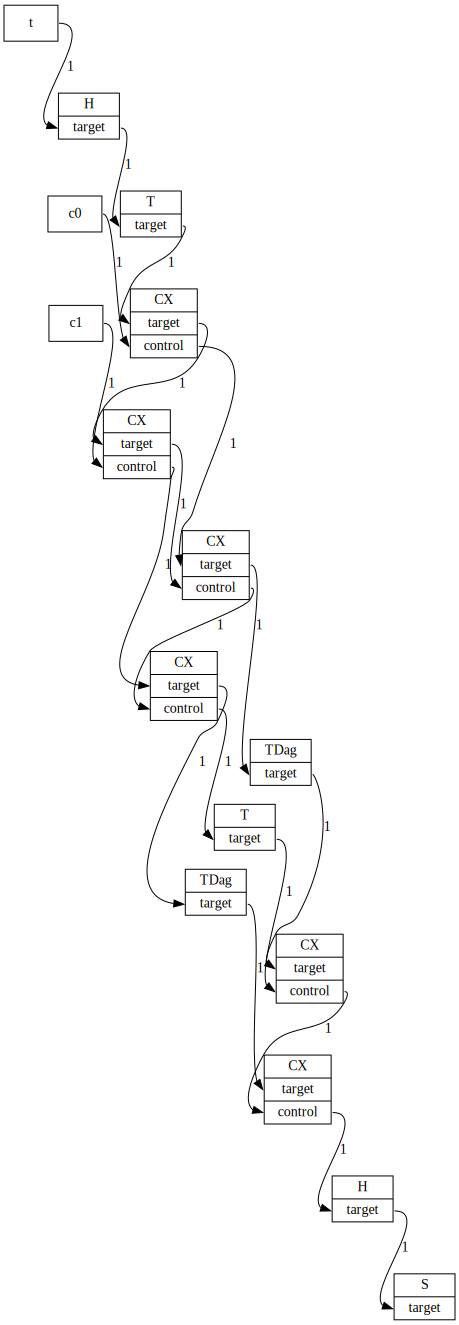

In [15]:
!qret diagram -i {example_path} --function "TemporalAnd" --graph-format "ComputeGraph" -o compute_graph.dot

graphviz.Source.from_file("compute_graph.dot")

### LaTeX

LaTeX は、図をレポートや論文向けに取り込める形式で出力するための形式です。

[quantikz](https://ctan.org/pkg/quantikz) というパッケージの形式で出力します。

In [16]:
!qret diagram -i {example_path} --function "AddCraig(5)" --graph-format "LaTeX" -o out.tex

Code(filename="out.tex", language="tex")

\begin{quantikz}[transparent]
    \lstick{dst[0]} & \qw \slice{entry} & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][4.75cm]{TemporalAnd} \qw \gateinput{op[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][7.00cm]{UncomputeTemporalAnd} \qw \gateinput{op[2]} & \targ{} & \qw & \qw & \qw & \qw & \qw \\
    \lstick{dst[1]} & \qw & \qw & \qw & \targ{} & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][4.75cm]{TemporalAnd} \qw \gateinput{op[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][7.00cm]{UncomputeTemporalAnd} \qw \gateinput{op[2]} & \qw & \qw & \qw & \targ{} & \qw & \qw & \qw & \qw \\
    \lstick{dst[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][4.75cm]{TemporalAnd} \qw \gateinput{op[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][7.00cm]{UncomputeTemporalAnd} \qw \gateinput{op[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \qw & \qw & \qw \\
    \lstick{dst[3]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][4.75cm]{TemporalAnd} \qw \gateinput{op[2]} & \qw & \qw & \qw & \gate[wires=11,nwires={1,2,3,4,5,6,7,8,9,10,11}][7.00cm]{UncomputeTemporalAnd} \qw \gateinput{op[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \qw & \qw \\
    \lstick{dst[4]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \qw \\
    \lstick{src[0]} & \qw & \qw \gateinput{op[1]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw \gateinput{op[1]} & \ctrl{-5} & \qw & \qw & \qw & \qw & \qw \\
    \lstick{src[1]} & \qw & \qw & \targ{} & \qw & \qw \gateinput{op[1]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw \gateinput{op[1]} & \targ{} & \qw & \qw & \ctrl{-5} & \qw & \qw & \qw & \qw \\
    \lstick{src[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \qw & \qw \gateinput{op[1]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw \gateinput{op[1]} & \targ{} & \qw & \qw & \qw & \qw & \qw & \qw & \ctrl{-5} & \qw & \qw & \qw \\
    \lstick{src[3]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \targ{} & \qw & \qw \gateinput{op[1]} & \qw & \qw & \qw & \qw \gateinput{op[1]} & \targ{} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \ctrl{-5} & \qw & \qw \\
    \lstick{src[4]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \ctrl{-5} & \qw \\
    \lstick{aux[0]} & \qw & \qw \gateinput{op[0]} & \ctrl{-4} & \ctrl{-9} & \qw & \ctrl{1} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \ctrl{1} & \qw & \ctrl{-4} & \qw \gateinput{op[0]} & \qw & \qw & \qw & \qw & \qw & \qw \\
    \lstick{aux[1]} & \qw & \qw & \qw & \qw & \qw \gateinput{op[0]} & \targ{} & \ctrl{-4} & \ctrl{-9} & \qw & \ctrl{1} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \ctrl{1} & \qw & \ctrl{-4} & \targ{} & \qw \gateinput{op[0]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw \\
    \lstick{aux[2]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw \gateinput{op[0]} & \targ{} & \ctrl{-4} & \ctrl{-9} & \qw & \ctrl{1} & \qw & \ctrl{1} & \qw & \ctrl{-4} & \targ{} & \qw \gateinput{op[0]} & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw & \qw \\
    \lstick{aux[3]} & \qw & \qw & \qw & \qw & \qw & \qw &

## qret simulate

`simulate` は、IR をシミュレートするためのサブコマンドです。

どのような方法で量子状態を保持してシミュレートするかということを `--state` という引数で指定できます。
現在サポートしているオプションは次の 2 つです。

- `Toffoli` : `(係数, 計算基底)` のリストとして量子状態を表現します。
    - `--max_superpositions` という引数で、このリストの長さの上限を設定します。デフォルトは 1 です。
    - 加算回路といった古典回路のシミュレートに適しています。
- `FullQuantum` : 量子ビット数を $n$ として $2^n$ のベクトルと量子状態を表現します。
    - 量子ビット数が少ない回路のシミュレートに適しています。

In [17]:
!qret simulate --help

qret 'simulate' options
Simulate a function in an IR file.

Examples:
  qret simulate --input <ir-file> --function <name>
  qret simulate --input <ir-file> --function <name> --state Toffoli --max_superpositions 16 --init_state 0101 --num_samples 8
  qret simulate --input <ir-file> --function <name> --state FullQuantum --print_raw
:
  -h [ --help ]                     Show this help and exit.
  --quiet                           Suppress non-error output.
  --verbose                         Enable verbose logging (more detail than 
                                    default).
  --debug                           Enable debug logging (most detailed; 
                                    implies --verbose).
  --color                           Enable colored output.
  -i [ --input ] arg                Path of input IR file.
  -f [ --function ] arg             Function name to simulate.
  -s [ --state ] arg (=FullQuantum) Simulation model. Allowed values: 
                                    

In [18]:
!qret simulate -i {example_path} -f "TemporalAnd" -s Toffoli --max_superpositions 2 --init_state "011"

[Run Configuration]
  function            TemporalAnd
  qubit_count         3
  model               Toffoli
  initial_state       011
  seed                1
  num_runs            1
  print_raw           false
  max_superpositions  2
[Argument Initialization]
  | name | size | bit_range | bits | value |
  |------|------|-----------|------|-------|
  | t    |    1 | q0        | 0    |     0 |
  | c0   |    1 | q1        | 1    |     1 |
  | c1   |    1 | q2        | 1    |     1 |
  note: bit order is q0 q1 ... in printed strings.
[Toffoli State]
  num_superpositions  1
[Final State]
  basis               111
  probability         1.000000
[Argument Final State]
  | name | size | bit_range | bits | value |
  |------|------|-----------|------|-------|
  | t    |    1 | q0        | 1    |     1 |
  | c0   |    1 | q1        | 1    |     1 |
  | c1   |    1 | q2        | 1    |     1 |
  note: bit order is q0 q1 ... in printed strings.
[Raw State]
  global_phase: (+1.000000+0.000000i)
  | 

In [19]:
!qret simulate -i {example_path} -f "TemporalAnd" -s FullQuantum --init_state "011"


[Run 1/10]
[Run Configuration]
  function            TemporalAnd
  qubit_count         3
  model               FullQuantum
  initial_state       011
  seed                1
  num_runs            10
  print_raw           false
  use_qulacs          false
[Argument Initialization]
  | name | size | bit_range | bits | value |
  |------|------|-----------|------|-------|
  | t    |    1 | q0        | 0    |     0 |
  | c0   |    1 | q1        | 1    |     1 |
  | c1   |    1 | q2        | 1    |     1 |
  note: bit order is q0 q1 ... in printed strings.
[FullQuantum State]
  num_superpositions  1
  entropy             6.66133814775e-16
[Samples]
  count: 1
     0: 111 (7)
[Final State]
  basis               111
  probability         1.000000
[Argument Final State]
  | name | size | bit_range | bits | value |
  |------|------|-----------|------|-------|
  | t    |    1 | q0        | 1    |     1 |
  | c0   |    1 | q1        | 1    |     1 |
  | c1   |    1 | q2        | 1    |     1 |
  n

最後に `AddCraig(5)` を `Toffoli` で実行し、加算が行われていることを確認します。

以下のコマンドで `dst` の量子ビットを `01100` で初期化し、 `src` の量子ビットを `11010` 初期化して in-place の加算を行います。
実行結果としては、 `dst` の量子ビットだけが `10001` に変化することが期待されます。

In [20]:
!qret simulate -i {example_path} -f "AddCraig(5)" -s Toffoli --max_superpositions 16 --init_state "0110011010000"

[Run Configuration]
  function            AddCraig(5)
  qubit_count         14
  model               Toffoli
  initial_state       01100110100000
  seed                1
  num_runs            1
  print_raw           false
  max_superpositions  16
[Argument Initialization]
  | name | size | bit_range | bits  | value |
  |------|------|-----------|-------|-------|
  | dst  |    5 | q[0..4]   | 01100 |     6 |
  | src  |    5 | q[5..9]   | 11010 |    11 |
  | aux  |    4 | q[10..13] | 0000  |     0 |
  note: bit order is q0 q1 ... in printed strings.
[Toffoli State]
  num_superpositions  1
[Final State]
  basis               10001110100000
  probability         1.000000
[Argument Final State]
  | name | size | bit_range | bits  | value |
  |------|------|-----------|-------|-------|
  | dst  |    5 | q[0..4]   | 10001 |    17 |
  | src  |    5 | q[5..9]   | 11010 |    11 |
  | aux  |    4 | q[10..13] | 0000  |     0 |
  note: bit order is q0 q1 ... in printed strings.
[Raw State]
  global

### （発展）古典的確率分布に従った量子回路の記述

Quration の中間表現では `DISCRETE_DISTRIBUTION` という命令があり、
ランダムな整数キーを classical レジスタ列として実体化し、
続く `SWITCH` で整数キーに対応する経路を選ぶ構成を作れます。
この例では、`q0, q1, q2` のいずれかへ 1/3 の確率で `X` を適用する分岐回路を構成します。

まず `DISCRETE_DISTRIBUTION` の挙動です。
- `weights` に応じて、`0` から `weights.size()-1` の整数値を 1 つ決定します。
- 決定した整数を、`registers` で与えたレジスタ列にビット列として書き込みます。
- この書き込みは LSB-first です。`@r0` が下位ビット（2^0）、`@r1` が次ビット（2^1）。

次に `SWITCH` のキー解釈です。
- `SWITCH` は `registers` レジスタ列を上位から下位ではなく、
  `registers[0]` を最下位ビットとして `BoolArrayAsInt` で整数化します。
- ここでの値は `0` 〜 `3` を扱う 2 ビット整数です。

具体的な対応は次のとおりです。
- `@r0=0, @r1=0` のとき: インデックス 0 → `case_X0`
- `@r0=1, @r1=0` のとき: インデックス 1 → `case_X1`
- `@r0=0, @r1=1` のとき: インデックス 2 → `case_X2`
- `@r0=1, @r1=1` のとき: インデックス 3 は `default`（それ以外の値は `return`）

各 case は 1 つの基本ブロックで、対応する 1 量子ビットへの `X` 実行後に `return` へ分岐します。
`weights = [1,1,1]` なので、`case_X0`,`case_X1`,`case_X2` はおおむね 1/3 ずつ選ばれます。
`index=3` はケース未定義なので `default` を通って `return` になります。
`simulate --sample_summary` では `100`,`010`,`001` がそれぞれほぼ等比率で観測され、
さらに文字列の並びは `q0 q1 q2`（LSB-first）である点を踏まえて `X` 適用先と対応づけられます。

まずサンプル入力ファイルを `dist_json` として固定し、以降の確認で同一入力を使える状態にします。

In [21]:
dist_json = "data/tutorial_2.json"

Code(
    filename=dist_json,
    language="json",
)

{
    "name": "Tutorial2Module",
    "circuit_list": [
        {
            "name": "Tutorial2Function",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "DiscreteDistribution",
                            "weights": [
                                1.0,
                                1.0,
                                1.0
                            ],
                            "registers": [
                                0,
                                1
                            ]
                        },
                        {
                            "opcode": "Switch",
                            "default": "default",
                            "case": [
                                "case_X0",
                                "case_X1",
                                "case_X2"
                            ],
                            "registers": [
                                0,
                                1
                            ]
                        }
                    ],
                    "predecessors": [],
                    "successors": [
                        "default",
                        "case_X0",
                        "case_X1",
                        "case_X2"
                    ]
                },
                {
                    "name": "case_X0",
                    "inst_list": [
                        {
                            "opcode": "X",
                            "q": 0
                        },
                        {
                            "opcode": "Branch",
                            "num_successors": 1,
                            "if_true": "switch_cont_0"
                        }
                    ],
                    "predecessors": [
                        "entry"
                    ],
                    "successors": [
                        "switch_cont_0"
                    ]
                },
                {
                    "name": "case_X1",
                    "inst_list": [
                        {
                            "opcode": "X",
                            "q": 1
                        },
                        {
                            "opcode": "Branch",
                            "num_successors": 1,
                            "if_true": "switch_cont_0"
                        }
                    ],
                    "predecessors": [
                        "entry"
                    ],
                    "successors": [
                        "switch_cont_0"
                    ]
                },
                {
                    "name": "case_X2",
                    "inst_list": [
                        {
                            "opcode": "X",
                            "q": 2
                        },
                        {
                            "opcode": "Branch",
                            "num_successors": 1,
                            "if_true": "switch_cont_0"
                        }
                    ],
                    "predecessors": [
                        "entry"
                    ],
                    "successors": [
                        "switch_cont_0"
                    ]
                },
                {
                    "name": "default",
                    "inst_list": [
                        {
                            "opcode": "Branch",
                            "num_successors": 1,
                            "if_true": "switch_cont_0"
                        }
                    ],
                    "predecessors": [
                        "entry"
                    ],
                    "successors": [
                        "switch_cont_0"
                    ]
                },
                {
         

この `print` で `DiscreteDistribution` と `Switch` の命令列を確認し、`case` の対応表をテキストで把握します。

In [22]:
!qret print -i {dist_json} -f "Tutorial2Function"

[Function]
Tutorial2Function:
 [block] entry
  DiscreteDistribution {1,1,1} @r0 @r1
  Switch [@r0 @r1] %switch_cont_0 [0: %case_X0 1: %case_X1 2: %case_X2]
 [block] case_X0
  X @q0
  Branch %switch_cont_0
 [block] case_X1
  X @q1
  Branch %switch_cont_0
 [block] case_X2
  X @q2
  Branch %switch_cont_0
 [block] switch_cont_0
  Return


次に CFG を描画して、`entry` から `case_X0/X1/X2` と `default` の流れを図で確認します。

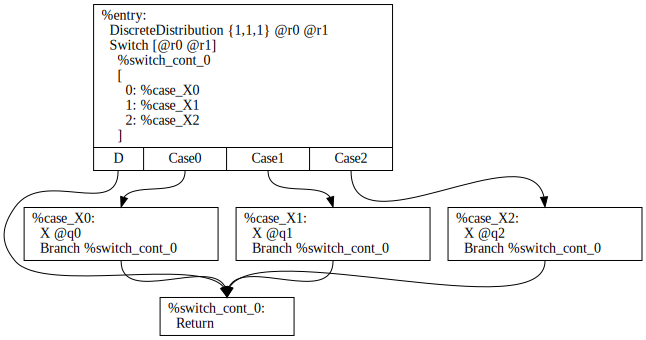

In [23]:
!qret diagram -i {dist_json} --function "Tutorial2Function" --graph-format "CFG" -o cfg.dot

graphviz.Source.from_file("cfg.dot")

最後に `simulate` でサンプル分布を確認し、`case` 3 つの観測確率が 1/3 付近になることを確認します。

In [24]:
!qret simulate -i {dist_json} -f "Tutorial2Function" -s FullQuantum --init_state "000" -n 10000 --sample_summary

[Samples Summary]
  function            Tutorial2Function
  num_runs            10000
  seed_range          1~10000
[Summary]
  count: 10000
  100: 3355 (33.55%)
  010: 3335 (33.35%)
  001: 3310 (33.10%)


## まとめ

- まず `print -s` でモジュール規模と関数一覧を確認し、調査対象を確定する
- 次に `print -f` で `FunctionCall` を軸に命令列を確認し、必要に応じて `-d` で展開深度を上げる
- `BasicBlock` を中心に `diagram --graph-format CFG` で分岐フローを把握する
- `CallGraph` で関数呼び出し依存を確認し、`ComputeGraph` でデータ依存を補完する